In [2]:
import kagglehub

path = kagglehub.dataset_download("pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-image-dataset-semantic-segmentation' dataset.
Path to dataset files: /kaggle/input/brain-tumor-image-dataset-semantic-segmentation


In [3]:
!pip install pycocotools

In [4]:
!pip install --upgrade scikit-image scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 16.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [5]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from pycocotools.coco import COCO
import os
import cv2 as cv

In [6]:
from pycocotools.coco import COCO

In [7]:
train_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/train'
val_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid'
test_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test'

train_annotation_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/train/_annotations.coco.json'
test_annotation_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test/_annotations.coco.json'
val_annotation_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid/_annotations.coco.json'

train_coco = COCO(train_annotation_file)
val_coco = COCO(val_annotation_file)
test_coco = COCO(test_annotation_file)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [8]:
def load_image_and_mask(coco, image_dir, image_id):
    image_info = coco.loadImgs(image_id)[0]
    image_path = os.path.join(image_dir, image_info['file_name'])
    image = Image.open(image_path)
    image = np.array(image)

    ann_ids = coco.getAnnIds(imgIds=image_id)
    anns = coco.loadAnns(ann_ids)
    mask = np.zeros((image_info['height'], image_info['width']))
    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    return image, mask



In [9]:
def create_tf_dataset(coco, image_dir, image_ids):
    def generator():
        for image_id in image_ids:
            yield load_image_and_mask(coco, image_dir, image_id)

    return tf.data.Dataset.from_generator(generator, output_signature=(tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8), tf.TensorSpec(shape=(None, None), dtype=tf.uint8)))

train_dataset = create_tf_dataset(train_coco, train_dir, train_coco.getImgIds())
val_dataset = create_tf_dataset(val_coco, val_dir, val_coco.getImgIds())
test_dataset = create_tf_dataset(test_coco, test_dir, test_coco.getImgIds())

In [10]:
def preprocess(image, mask):

    image = tf.image.resize(image, (256, 256))

    mask = tf.expand_dims(mask, axis=-1)
    mask = tf.image.resize(mask, (256, 256))

    image = tf.cast(image, tf.float32) / 255.0

    return image, mask

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

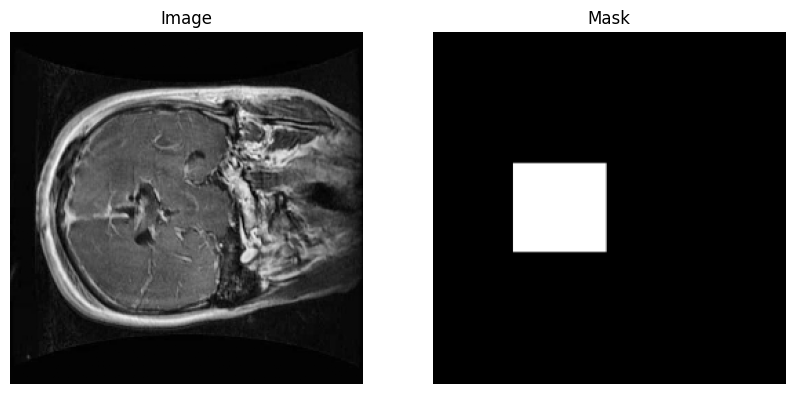

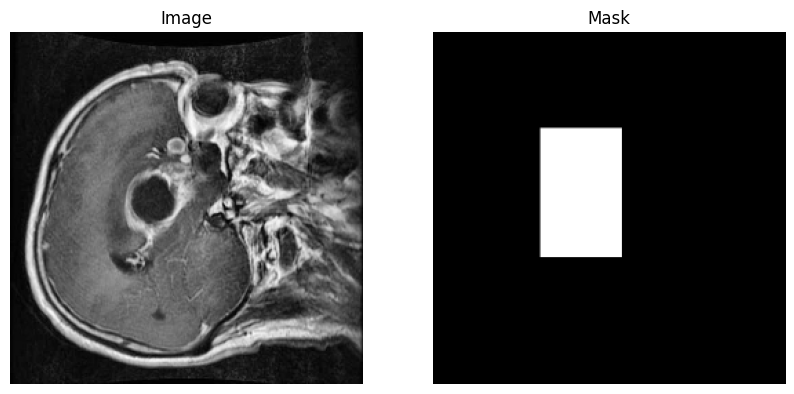

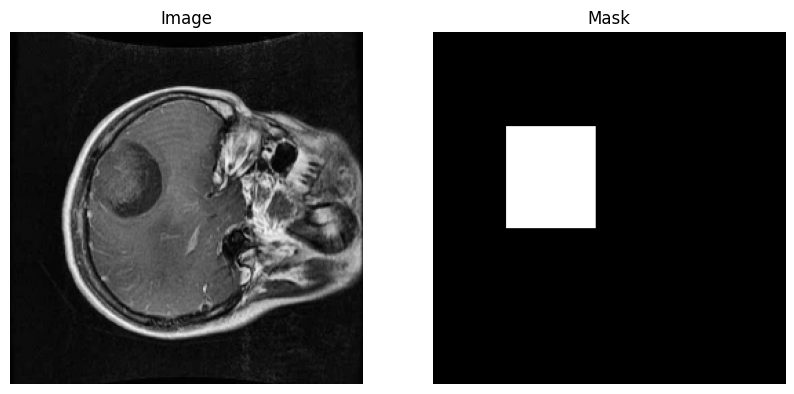

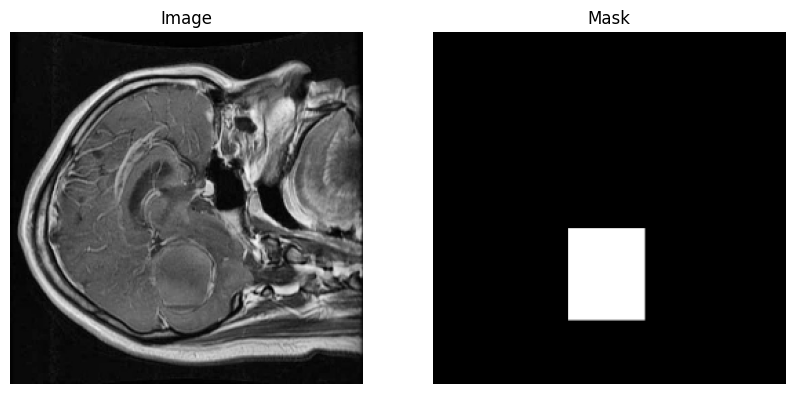

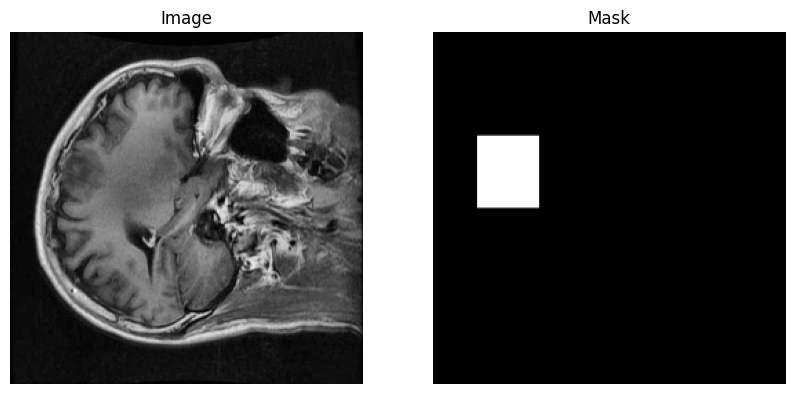

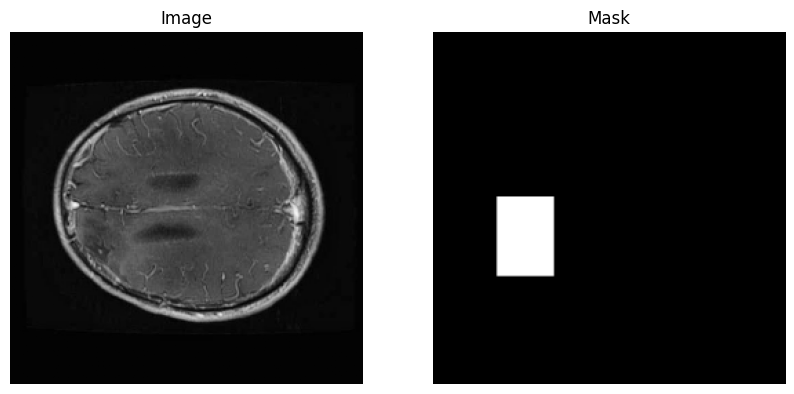

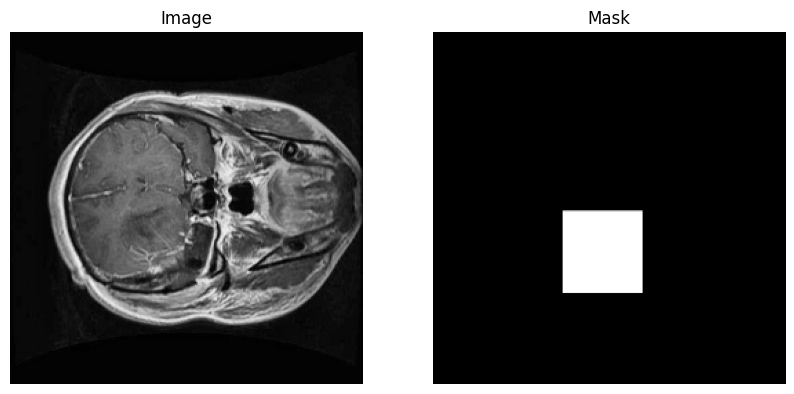

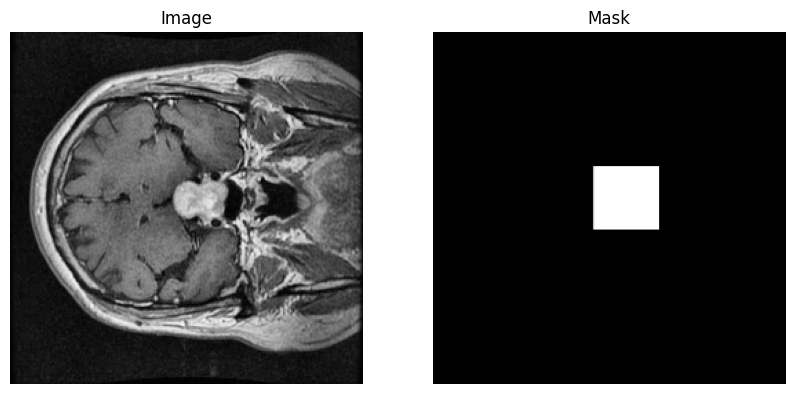

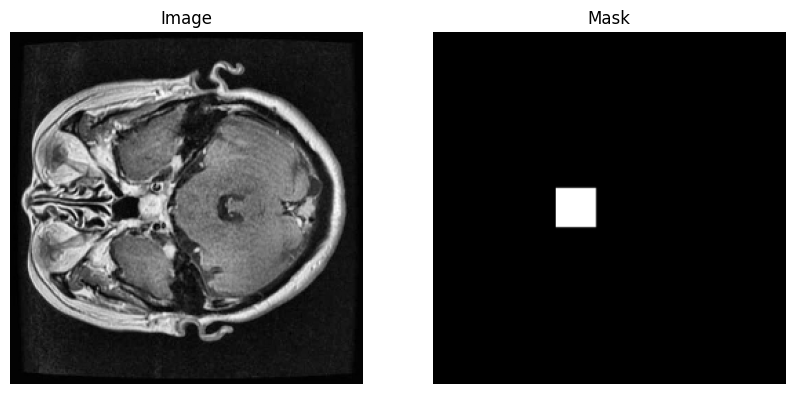

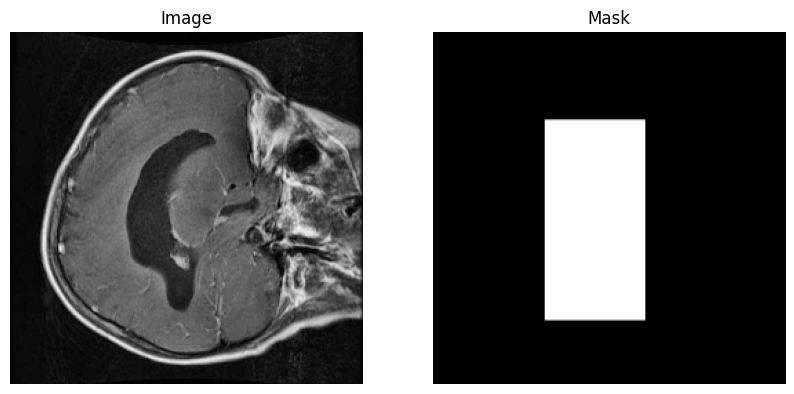

In [11]:
def visualize_dataset(dataset, num_samples=5):
    for i, (image, mask) in enumerate(dataset.take(num_samples)):
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(image.numpy())
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(mask.numpy().squeeze(), cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        plt.show()

visualize_dataset(train_dataset)
visualize_dataset(val_dataset)

In [12]:
def downsampling_block(x, n_filters):
    c = layers.Conv2D(n_filters, (3, 3), activation='relu', padding='same')(x)
    c = layers.Conv2D(n_filters, (3, 3), activation='relu', padding='same')(c)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p

def upsampling_block(x, skip_connection, n_filters):
    u = layers.Conv2DTranspose(n_filters, (2, 2), strides=(2, 2), padding='same')(x)
    u = layers.concatenate([u, skip_connection])
    c = layers.Conv2D(n_filters, (3, 3), activation='relu', padding='same')(u)
    c = layers.Conv2D(n_filters, (3, 3), activation='relu', padding='same')(c)
    return c

def unet_model(input_size=(256, 256, 3), n_filters=32, n_classes=1):
    inputs = layers.Input(input_size)

    dblock1, p1 = downsampling_block(inputs, n_filters)
    dblock2, p2 = downsampling_block(p1, n_filters * 2)
    dblock3, p3 = downsampling_block(p2, n_filters * 4)
    dblock4, p4 = downsampling_block(p3, n_filters * 8)

    bottleneck = layers.Conv2D(n_filters * 16, (3, 3), activation='relu', padding='same')(p4)
    bottleneck = layers.Conv2D(n_filters * 16, (3, 3), activation='relu', padding='same')(bottleneck)

    u6 = upsampling_block(bottleneck, dblock4, n_filters * 8)
    u7 = upsampling_block(u6, dblock3, n_filters * 4)
    u8 = upsampling_block(u7, dblock2, n_filters * 2)
    u9 = upsampling_block(u8, dblock1, n_filters)

    outputs = layers.Conv2D(n_classes, (1, 1), activation='sigmoid' if n_classes == 1 else 'softmax')(u9)

    model = models.Model(inputs, outputs)

    return model

model = unet_model(input_size=(256, 256, 3), n_filters=32)

In [13]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    dice = dice_loss(y_true, y_pred)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.6 * dice + 0.4 * bce

metrics = ["accuracy", dice_coef]

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=combined_loss, metrics=metrics)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.repeat().batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.repeat().batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

steps_per_epoch = len(train_coco.getImgIds()) // BATCH_SIZE
validation_steps = len(val_coco.getImgIds()) // BATCH_SIZE
test_steps = len(test_coco.getImgIds()) // BATCH_SIZE

In [15]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=4, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 84s 430ms/step - accuracy: 0.9585 - dice_coef: 0.0622 - loss: 0.7040 - val_accuracy: 0.9627 - val_dice_coef: 0.1530 - val_loss: 0.5790 - learning_rate: 1.0000e-04
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 332ms/step - accuracy: 0.9629 - dice_coef: 0.1661 - loss: 0.5636 - val_accuracy: 0.9627 - val_dice_coef: 0.1891 - val_loss: 0.5569 - learning_rate: 1.0000e-04
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 352ms/step - accuracy: 0.9628 - dice_coef: 0.2095 - loss: 0.5315 - val_accuracy: 0.9627 - val_dice_coef: 0.2216 - val_loss: 0.5255 - learning_rate: 1.0000e-04
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 34s 366ms/step - accuracy: 0.9437 - dice_coef: 0.2332 - loss: 0.5151 - val_accuracy: 0.9483 - val_dice_coef: 0.2371 - val_loss: 0.5145 - learning_rate: 1.0000e-04
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 348ms/step - accuracy: 0.9364 - dice_coef: 0.2809 - loss: 0.4897 - val_accuracy: 0.9616 - val_dice_coef: 0.3040 - val_loss: 0.4757 - learning_rate: 1

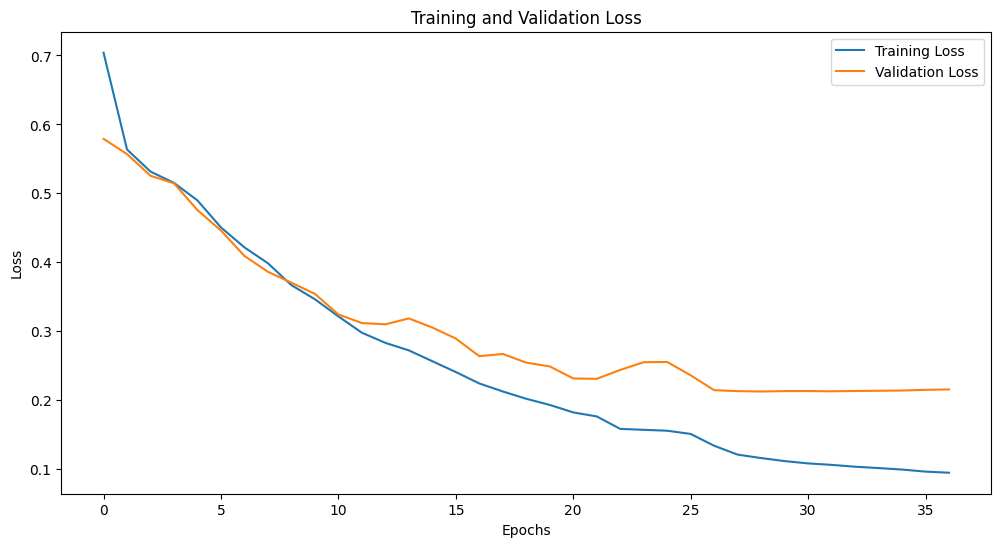

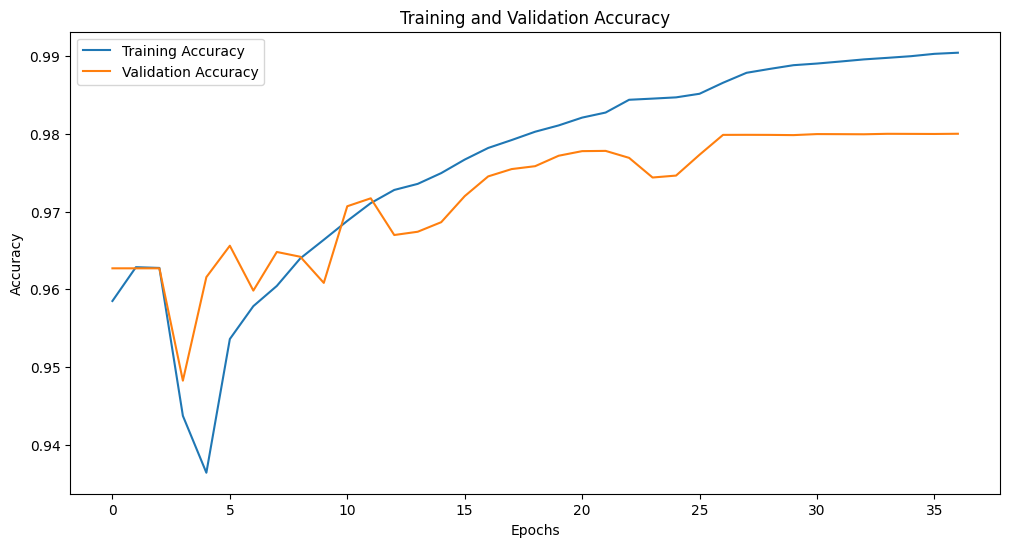

In [16]:
def plot_loss(history):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_accuracy(history):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_loss(history)
plot_accuracy(history)

In [17]:
test_loss, test_accuracy, test_coef = model.evaluate(test_dataset, steps=test_steps)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}, Test Dice Coefficient: {test_coef}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.9804 - dice_coef: 0.7156 - loss: 0.2077
Test Loss: 0.20767930150032043, Test Accuracy: 0.9803709387779236, Test Dice Coefficient: 0.7155863642692566


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


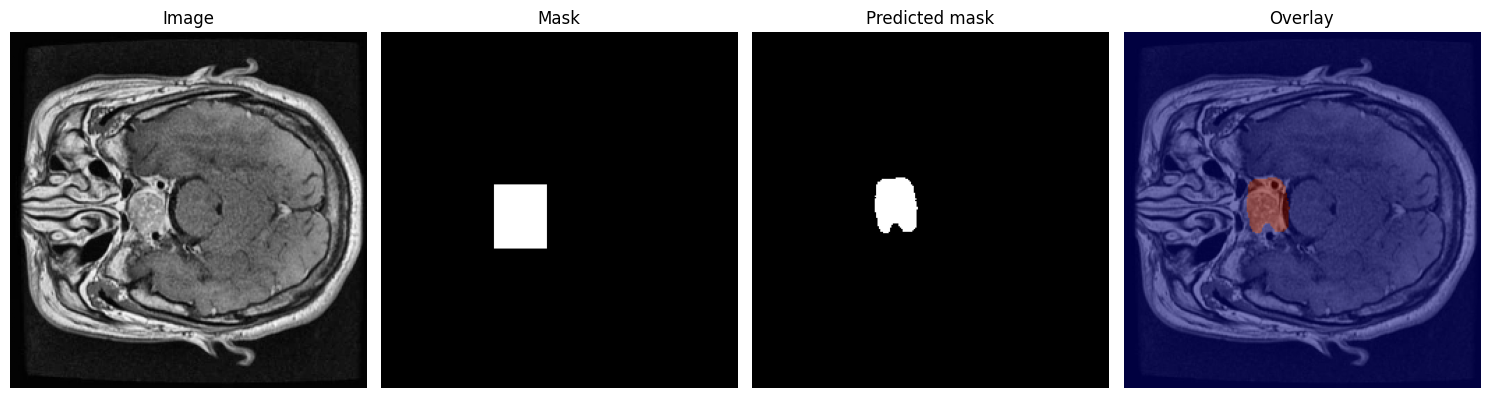

In [22]:
import random
def visualize_predictions(model, dataset, num_samples=5, threshold=0.5):

    random_batch = random.choice(list(dataset))
    images, masks = random_batch

    indices = random.sample(range(len(images)), min(num_samples, len(images)))

    predictions = model.predict(images)

    binary_predictions = (predictions > threshold).astype('uint8')

    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    for i in indices:
        axes[0].imshow(images[i])
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(masks[i].numpy().squeeze(), cmap='gray')
        axes[1].set_title("Mask")
        axes[1].axis("off")

        axes[2].imshow(binary_predictions[i].squeeze(), cmap='gray')
        axes[2].set_title("Predicted mask")
        axes[2].axis("off")

        axes[3].imshow(images[i])
        axes[3].imshow(binary_predictions[i].squeeze(), cmap='jet', alpha=0.5)
        axes[3].set_title("Overlay")
        axes[3].axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, num_samples=10)